In [1]:
!nrnivmodl /home/wzl/LFPy/project/conductance_measurement/realistic_neuron/purkinjecell_2015/mod_files
from neuron import h
from neuron.units import ms, mV
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import plotly
from neuron import clear_gui_callback
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from scipy.integrate import cumtrapz
from numpy.linalg import pinv, eig
import numpy as np
from multiprocessing import Pool
font2={'family':'Times New Roman',
'weight':'bold',
'size': 10}
# 自定义刻度标签显示格式

from matplotlib.ticker import FuncFormatter
def format_func(value, tick_number):
    return f'{value:.0f}'  # 将刻度值格式化为小数点后两位

def plot_curve(ax2,x,y,color='black',title='', linestyle='-',xlim=[0,100],dx=20,ylim=[0,10],dy=5.0, fontsize=10, alpha = 1.0, xlabel='Time/ms', ylabel = 'Frequency/Hz', label='',ynum_decimals =1):
    if color:
        ax2.plot(x,y,color=color,linewidth=2,linestyle=linestyle,alpha=alpha, label=label)
    else:
        ax2.plot(x,y,linewidth=2,alpha=alpha, linestyle=linestyle,label=label)
    ax2.set_xlabel(xlabel,font2)
    ax2.set_ylabel(ylabel,font2)
    
    # def format_funcx(value, tick_number, num_decimals=xnum_decimals):
    #     if num_decimals==0:
    #         return f'{value:.0f}'
    #     return f'{value:.{num_decimals}f}'

    def format_funcy(value, tick_number, num_decimals=ynum_decimals):
        if num_decimals==0:
          return f'{value:.0f}'
        return f'{value:.{num_decimals}f}'

    # if dx:
    #     ax2.set_xticks(np.arange(xlim[0], xlim[1] + dx, dx))
    #     ax2.set_xticklabels(ax2.get_xticks(), fontsize=fontsize, weight='bold')
    #     ax2.set_xlim([xlim[0], xlim[1]])
    #     ax2.xaxis.set_major_formatter(FuncFormatter(format_funcx))

    if dy:
        ax2.set_yticks(np.arange(ylim[0], ylim[1] + dy, dy))
        ax2.set_yticklabels(ax2.get_yticks(), fontsize=fontsize, weight='bold')
        ax2.set_ylim([ylim[0], ylim[1]])
        ax2.yaxis.set_major_formatter(FuncFormatter(format_funcy))
        
  
    if xlim:
       ax2.set_xticks(np.arange(xlim[0],xlim[1]+dx,dx))
       ax2.set_xticklabels(np.arange(xlim[0],xlim[1]+dx,dx),fontsize=10,weight='bold')
       ax2.set_xlim(xlim)
    # if ylim:
    #    ax2.set_yticks(np.arange(ylim[0],ylim[1]+dy,dy))
    #    ax2.set_yticklabels(np.arange(ylim[0],ylim[1]+dy,dy),fontsize=10,weight='bold')
    #    ax2.set_ylim(ylim)
    if title:
       ax2.set_title('{0}'.format(title),fontsize=12,weight='bold')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    if label:
       ax2.legend(loc='best',prop=font2,edgecolor='white')

h.load_file('nrngui.hoc')
h.load_file("import3d.hoc")
from neuron import h
import numpy as np
import random
import math


#import of the dictionary with the conductance
from PC_param import pc_param 
class Purkinje_py3:
    def __init__(self):

#Soma        
        self.soma = h.Section(name='soma')
        self.soma.nseg = 1
        self.soma.diam = 29.8
        self.soma.cm = 0.77
        self.soma.L =  29.8
        self.soma.Ra = 122

        self.soma.insert('Leak')
        self.soma.e_Leak = pc_param['eleak']
        self.soma.gmax_Leak = pc_param['LeakSoma']
        
        self.soma.insert('Cav3_1') 
        self.soma.pcabar_Cav3_1 = pc_param['Cav3.1Soma']
        
        self.soma.insert('Cav2_1') 
        self.soma.pcabar_Cav2_1 = pc_param['Cav2.1Soma']
            
        self.soma.insert('HCN1')
        self.soma.gbar_HCN1 = pc_param['HCNSoma']
        self.soma.eh = -34.4

        self.soma.insert('Nav1_6')
        self.soma.gbar_Nav1_6 = pc_param['Nav1.6Soma']
        self.soma.ena = 60
        
        self.soma.insert('Kv3_4')
        self.soma.gkbar_Kv3_4 = pc_param['Kv3.4Soma']
        self.soma.ek = -88
        
        self.soma.insert('Kv1_1')
        self.soma.gbar_Kv1_1 = pc_param['Kv1.1Soma']
        
        self.soma.insert('Cav3_2')
        self.soma.gcabar_Cav3_2 = pc_param['Cav3.2Soma']
        
        self.soma.insert('Kca3_1')
        self.soma.gkbar_Kca3_1 = pc_param['Kca3.1Soma']
        
        self.soma.insert('Cav3_3')
        self.soma.pcabar_Cav3_3 = pc_param['Cav3.3Soma']

        self.soma.insert('Kir2_3')
        self.soma.gkbar_Kir2_3 = pc_param['PC_KirSoma']
        
        self.soma.insert('Kca1_1')
        self.soma.gbar_Kca1_1 = pc_param['Kca1.1Soma']
        
        self.soma.insert('Kca2_2') 
        self.soma.gkbar_Kca2_2 = pc_param['Kca2.2Soma']
        
        self.soma.insert('cdp5')
        self.soma.Nannuli_cdp5 = 0.326 + (1.94 * (self.soma.diam)) + (0.289*(self.soma.diam)*(self.soma.diam)) - ((3.33e-2)*(self.soma.diam)*(self.soma.diam)*(self.soma.diam)) + ((1.55e-3)*(self.soma.diam)*(self.soma.diam)*(self.soma.diam)*(self.soma.diam)) - (2.55e-5*(self.soma.diam)*(self.soma.diam)*(self.soma.diam)*(self.soma.diam)*(self.soma.diam))
        self.soma.Buffnull2_cdp5 = 64.2 - 57.3* math.exp(-(self.soma.diam)/1.4)
        self.soma.rf3_cdp5 = 0.162 - 0.106* math.exp(-(self.soma.diam)/2.29)
        self.soma.rf4_cdp5 = 0.000267 + 0.0167* math.exp(-(self.soma.diam)/0.722) + 0.0028* math.exp(-(self.soma.diam)/4)
        
        self.soma.TotalPump_cdp5 = 5e-8
        
        self.soma.push()
        h.pt3dclear()
        h.pt3dadd(0.0, 0, 0.0, 29.8)
        h.pt3dadd(0.0, 29.8, 0.0, 29.8)
        h.pop_section()
        
        self.soma.push()
        h.ion_style("ca_ion", 1, 1, 0, 1, 0) 
        self.soma.eca = 137.52625 
        self.soma.cai = h.cai0_ca_ion
        self.soma.cao = h.cao0_ca_ion
        h.pop_section()

#Dend coordinate
        self.sectioncoordinate = np.genfromtxt("coordinate.csv")

        fh = open("PC_dendnames.dlist")
        self.dendnames = [line[:-1] for line in fh.readlines()]
        
        self.dend = []
        for i_idx,i in enumerate(self.sectioncoordinate):
            self.dend.append(h.Section(name=self.dendnames[i_idx]))
            self.dend[-1].push()
            h.pt3dclear()
            h.pt3dadd(i.item(1), i.item(2), i.item(3), i.item(4))
            h.pt3dadd(i.item(5), i.item(6), i.item(7), i.item(8))
            self.dend[-1].diam = i.item(4)

            self.dend[-1].insert('cdp5')
            self.dend[-1].Nannuli_cdp5 = 0.326 + (1.94 * (i.item(8))) + (0.289*(i.item(8))*(i.item(8))) - ((3.33e-2)*(i.item(8))*(i.item(8))*(i.item(8))) + ((1.55e-3)*(i.item(8))*(i.item(8))*(i.item(8))*(i.item(8))) - (2.55e-5*(i.item(8))*(i.item(8))*(i.item(8))*(i.item(8))*(i.item(8)))
            self.dend[-1].Buffnull2_cdp5 = 64.2 - 57.3* math.exp(-(i.item(8))/1.4)
            self.dend[-1].rf3_cdp5 = 0.162 - 0.106* math.exp(-(i.item(8))/2.29)
            if ((i.item(8))>=2):
                self.dend[-1].rf4_cdp5 = 0.000267 + 0.0167* math.exp(-(i.item(8))/0.722) + 0.0028* math.exp(-(i.item(8))/4)
            else:
                self.dend[-1].rf4_cdp5 = 0.003
            
            h.pop_section()

#Connection between dend and soma  
        self.dend[0].connect(self.soma,1,0)

#Connection between each dend	
        for c in np.genfromtxt("connections.csv"):
            self.dend[int(c[0])].connect(self.dend[int(c[2])],int(c[3]),int(c[1]))
	   

        self.subsets = np.genfromtxt("ModelViewParmSubset.txt", dtype = int)
        self.ModelViewParmSubset = [[self.dend[int(i)] for i in self.subsets[np.where(self.subsets[...,1]==M),0][0]] for M in range(88) ]
        for d in self.dend:
            
            d.Ra = 122
            
            d.insert('Leak')
            d.e_Leak = pc_param['eleak']
    
            d.insert('Cav2_1') 
            d.pcabar_Cav2_1 = pc_param['Cav2.1Dend']
        
            d.insert('Kca1_1')
            d.gbar_Kca1_1 = pc_param['Kca1.1Dend']
            
            d.insert('Kv4_3')
            d.gkbar_Kv4_3 = pc_param['Kv4.3Dend']

            d.insert('Kv1_1')
            d.gbar_Kv1_1 = pc_param['Kv1.1Dend']
            
            d.insert('Kv1_5')
            d.gKur_Kv1_5 = pc_param['Kv1.5Dend']
            
            d.insert('Kv3_3')
            d.gbar_Kv3_3 = pc_param['Kv3.3Dend']
            
            d.insert('Cav3_3')
            d.pcabar_Cav3_3 = pc_param['Cav3.3Dend']
            
            d.insert('HCN1')
            d.gbar_HCN1 = pc_param['HCNDend']
            d.eh = -34.4
                
            if d.diam >= 3.5 and d.diam <= 12: 
                d.insert('Cav3_2')
                d.gcabar_Cav3_2 = pc_param['Cav3.2Dend']
                
                d.insert('Kca3_1') 
                d.gkbar_Kca3_1 = pc_param['Kca3.1Dend']
                
                d.insert('Cav3_1') 
                d.pcabar_Cav3_1 = pc_param['Cav3.1Dend']
                
                d.insert('Kca2_2') 
                d.gkbar_Kca2_2 = pc_param['Kca2.2Dend']
                
                d.insert('Kir2_3')
                d.gkbar_Kir2_3 = pc_param['PC_KirDend']
                
                if d.diam >=8 and d.diam <=12:
                    d.insert('Nav1_6')
                    d.gbar_Nav1_6 = pc_param['Nav1.6Dend']
                    d.ena = 60
                
            d.TotalPump_cdp5 = 2e-8
            
            d.ek = -88
            
            d.push()
            d.eca = 137.52625
            d.cai = h.cai0_ca_ion
            d.cao = h.cao0_ca_ion
            h.ion_style("ca_ion", 1, 1, 0, 1, 0)
            h.pop_section()
            
            
            
	      
        self.subsets_cm = np.genfromtxt("ModelViewParmSubset_cm.txt")
        for cm in self.subsets_cm:
            for d in self.ModelViewParmSubset[int(cm[0])]:
                d.cm = cm[1] * 0.77/1.64

        self.dend[138].cm = 8.58298 * 0.77/1.64

        self.subsets_paraextra = np.genfromtxt("modelsubsetextra.txt", dtype=[('modelviewsubset','f8'),('channel','U4'),('channel2','U4'),('value','f8')], delimiter=" ")
        for para in self.subsets_paraextra:
            for d in self.ModelViewParmSubset[int(para[0])]:
                d.insert(para[1])
                exec('d.gmax_'+para[2]+' = '+str(para[3]))
	
        listgmax = []
        for d in self.ModelViewParmSubset[2]:
            d.gmax_Leak = d.gmax_Leak/2
            
        self.dend[138].insert('Leak')
        self.dend[138].gmax_Leak = 1.74451E-4 / 2
 	
#Axon AIS. First section after the soma
        self.axonAIS = h.Section(name='axonAIS')
        self.axonAIS.nseg = 1
        self.axonAIS.diam = 0.97 
        self.axonAIS.cm = 0.77
        self.axonAIS.L = 17
        self.axonAIS.Ra = 122
        
        self.axonAIS.insert('Leak')
        self.axonAIS.e_Leak = pc_param['eleak']
        self.axonAIS.gmax_Leak = 0.0003
        
        self.axonAIS.insert('Nav1_6')
        self.axonAIS.gbar_Nav1_6 = pc_param['Nav1.6AIS']
        self.axonAIS.ena = 75	
        
        self.axonAIS.insert('Cav3_1') 
        self.axonAIS.pcabar_Cav3_1 = pc_param['Cav3.1Ais']
        
        self.axonAIS.insert('Cav2_1') 
        self.axonAIS.pcabar_Cav2_1 = pc_param['Cav2.1AIS']
        
        self.axonAIS.insert('Kv3_4')
        self.axonAIS.gkbar_Kv3_4 = pc_param['Kv3.4AIS']
        self.axonAIS.ek = -88
        
        self.axonAIS.insert('cdp5')
        self.axonAIS.Nannuli_cdp5 = 0.326 + (1.94 * (self.axonAIS.diam)) + (0.289*(self.axonAIS.diam)*(self.axonAIS.diam)) - ((3.33e-2)*(self.axonAIS.diam)*(self.axonAIS.diam)*(self.axonAIS.diam)) + ((1.55e-3)*(self.axonAIS.diam)*(self.axonAIS.diam)*(self.axonAIS.diam)*(self.axonAIS.diam)) - (2.55e-5*(self.axonAIS.diam)*(self.axonAIS.diam)*(self.axonAIS.diam)*(self.axonAIS.diam)*(self.axonAIS.diam))
        self.axonAIS.Buffnull2_cdp5 = 64.2 - 57.3* math.exp(-(self.axonAIS.diam)/1.4)
        self.axonAIS.rf3_cdp5 = 0.162 - 0.106* math.exp(-(self.axonAIS.diam)/2.29)
        self.axonAIS.rf4_cdp5 = 0.003

        self.axonAIS.TotalPump_cdp5 = 5e-8
        
        self.axonAIS.push()
        h.ion_style("ca_ion", 1, 1, 0, 1, 0) 
        self.axonAIS.eca = 137.52625
        self.axonAIS.cai = h.cai0_ca_ion
        self.axonAIS.cao = h.cao0_ca_ion
        h.pop_section()
	
#AISK	
        self.axonAISK = h.Section(name='axonAISK')
        self.axonAISK.nseg = 1
        self.axonAISK.diam = 0.97 
        self.axonAISK.cm = 0.77
        self.axonAISK.L = 4 
        self.axonAISK.Ra = 122
        
        self.axonAISK.insert('Leak')
        self.axonAISK.e_Leak = pc_param['eleak']
        self.axonAISK.gmax_Leak = 0.0003
        
        self.axonAISK.insert('Kv1_1')
        self.axonAISK.gbar_Kv1_1 = pc_param['Kv1.1AisK']
        self.axonAISK.ek = -88
	
#First Myelination
        self.axonmyelin = h.Section(name='axonmyelin')
        self.axonmyelin.nseg = 1
        self.axonmyelin.diam = 0.73
        self.axonmyelin.L = 100

        self.axonmyelin.insert('pas') 
        self.axonmyelin.e_pas = -63 
        self.axonmyelin.g_pas = 5.60e-9 
        self.axonmyelin.cm = 1.87e-11
        self.axonmyelin.Ra = 122	
	
#First Node of Ranvier
        self.axonNOR = h.Section(name='axonNOR')
        self.axonNOR.nseg = 1
        self.axonNOR.diam = 0.73 
        self.axonNOR.cm = 0.77
        self.axonNOR.L = 4 
        self.axonNOR.Ra = 122
        
        self.axonNOR.insert('Leak')
        self.axonNOR.e_Leak = pc_param['eleak']
        self.axonNOR.gmax_Leak = 0.0003
        
        self.axonNOR.insert('Nav1_6')
        self.axonNOR.gbar_Nav1_6 = pc_param['Nav1.6Nor']
        self.axonNOR.ena = 60

        self.axonNOR.insert('Kv3_4')
        self.axonNOR.gkbar_Kv3_4 = pc_param['Kv3.4Nor']
        self.axonNOR.ek = -88
            
        self.axonNOR.insert('cdp5')
        self.axonNOR.Nannuli_cdp5 = 0.326 + (1.94 * (self.axonNOR.diam)) + (0.289*(self.axonNOR.diam)*(self.axonNOR.diam)) - ((3.33e-2)*(self.axonNOR.diam)*(self.axonNOR.diam)*(self.axonNOR.diam)) + ((1.55e-3)*(self.axonNOR.diam)*(self.axonNOR.diam)*(self.axonNOR.diam)*(self.axonNOR.diam)) - (2.55e-5*(self.axonNOR.diam)*(self.axonNOR.diam)*(self.axonNOR.diam)*(self.axonNOR.diam)*(self.axonNOR.diam))
        self.axonNOR.Buffnull2_cdp5 = 64.2 - 57.3* math.exp(-(self.axonNOR.diam)/1.4)
        self.axonNOR.rf3_cdp5 = 0.162 - 0.106* math.exp(-(self.axonNOR.diam)/2.29)
        self.axonNOR.rf4_cdp5 = 0.003
            
        self.axonNOR.insert('Cav3_1') 
        self.axonNOR.pcabar_Cav3_1 = pc_param['Cav3.1Nor']
        
        self.axonNOR.insert('Cav2_1') 
        self.axonNOR.pcabar_Cav2_1 = pc_param['Cav2.1Nor']
        
        self.axonNOR.TotalPump_cdp5 = 5e-7
	
#second part of the axon
        self.axonmyelin2 = h.Section(name='axonmyelin2')
        self.axonmyelin2.nseg = 1
        self.axonmyelin2.diam = 0.73
        self.axonmyelin2.L = 100 
        
        self.axonmyelin2.insert('pas') 
        self.axonmyelin2.e_pas = -63 
        self.axonmyelin2.g_pas = 5.60e-9 
        self.axonmyelin2.cm = 1.87e-11 
        self.axonmyelin2.Ra = 122
	
#Second Node of Ranvier	
        self.axonNOR2 = h.Section(name='axonNOR2')
        self.axonNOR2.nseg = 1
        self.axonNOR2.diam = 0.73 
        self.axonNOR2.cm = 0.77
        self.axonNOR2.L = 4 
        self.axonNOR2.Ra = 122
        
        self.axonNOR2.insert('Leak')
        self.axonNOR2.e_Leak = pc_param['eleak']
        self.axonNOR2.gmax_Leak = 0.0003
        
        self.axonNOR2.insert('Nav1_6')
        self.axonNOR2.gbar_Nav1_6 = pc_param['Nav1.6Nor2']
        self.axonNOR2.ena = 60

        self.axonNOR2.insert('Kv3_4')
        self.axonNOR2.gkbar_Kv3_4 = pc_param['Kv3.4Nor2']
        self.axonNOR2.ek = -88

        self.axonNOR2.insert('cdp5')
        self.axonNOR2.Nannuli_cdp5 = 0.326 + (1.94 * (self.axonNOR2.diam)) + (0.289*(self.axonNOR2.diam)*(self.axonNOR2.diam)) - ((3.33e-2)*(self.axonNOR2.diam)*(self.axonNOR2.diam)*(self.axonNOR2.diam)) + ((1.55e-3)*(self.axonNOR2.diam)*(self.axonNOR2.diam)*(self.axonNOR2.diam)*(self.axonNOR2.diam)) - (2.55e-5*(self.axonNOR2.diam)*(self.axonNOR2.diam)*(self.axonNOR2.diam)*(self.axonNOR2.diam)*(self.axonNOR2.diam))
        self.axonNOR2.Buffnull2_cdp5 = 64.2 - 57.3* math.exp(-(self.axonNOR2.diam)/1.4)
        self.axonNOR2.rf3_cdp5 = 0.162 - 0.106* math.exp(-(self.axonNOR2.diam)/2.29)
        self.axonNOR2.rf4_cdp5 = 0.003
        
        self.axonNOR2.insert('Cav3_1') 
        self.axonNOR2.pcabar_Cav3_1 = pc_param['Cav3.1Nor2']
        
        self.axonNOR2.insert('Cav2_1') 
        self.axonNOR2.pcabar_Cav2_1 = pc_param['Cav2.1Nor2']
        
        self.axonNOR2.TotalPump_cdp5 = 5e-7
	
#Third part of the axon
        self.axonmyelin3 = h.Section(name='axonmyelin3')
        self.axonmyelin3.nseg = 1
        self.axonmyelin3.diam = 0.73
        self.axonmyelin3.L = 100 
        
        self.axonmyelin3.insert('pas') 
        self.axonmyelin3.e_pas = -63 
        self.axonmyelin3.g_pas = 5.60e-9 
        self.axonmyelin3.cm = 1.87e-11 
        self.axonmyelin3.Ra = 122
	
#Third Node of Ranvier
        self.axonNOR3 = h.Section(name='axonNOR3')
        self.axonNOR3.nseg = 1
        self.axonNOR3.diam = 0.73 
        self.axonNOR3.cm = 0.77
        self.axonNOR3.L = 4 
        self.axonNOR3.Ra = 122
        
        self.axonNOR3.insert('Leak')
        self.axonNOR3.e_Leak = pc_param['eleak']
        self.axonNOR3.gmax_Leak = 0.0003
        
        self.axonNOR3.insert('Nav1_6')
        self.axonNOR3.gbar_Nav1_6 = pc_param['Nav1.6Nor3']
        self.axonNOR3.ena = 60

        self.axonNOR3.insert('Kv3_4')
        self.axonNOR3.gkbar_Kv3_4 = pc_param['Kv3.4Nor3']
        self.axonNOR3.ek = -88
        
        self.axonNOR3.insert('cdp5')
        self.axonNOR3.Nannuli_cdp5 = 0.326 + (1.94 * (self.axonNOR3.diam)) + (0.289*(self.axonNOR3.diam)*(self.axonNOR3.diam)) - ((3.33e-2)*(self.axonNOR3.diam)*(self.axonNOR3.diam)*(self.axonNOR3.diam)) + ((1.55e-3)*(self.axonNOR3.diam)*(self.axonNOR3.diam)*(self.axonNOR3.diam)*(self.axonNOR3.diam)) - (2.55e-5*(self.axonNOR3.diam)*(self.axonNOR3.diam)*(self.axonNOR3.diam)*(self.axonNOR3.diam)*(self.axonNOR3.diam))
        self.axonNOR3.Buffnull2_cdp5 = 64.2 - 57.3* math.exp(-(self.axonNOR3.diam)/1.4)
        self.axonNOR3.rf3_cdp5 = 0.162 - 0.106* math.exp(-(self.axonNOR3.diam)/2.29)
        self.axonNOR3.rf4_cdp5 = 0.003
        
        self.axonNOR3.insert('Cav3_1') 
        self.axonNOR3.pcabar_Cav3_1 = pc_param['Cav3.1Nor3']
        
        self.axonNOR3.insert('Cav2_1') 
        self.axonNOR3.pcabar_Cav2_1 = pc_param['Cav2.1Nor3']
        
        self.axonNOR3.TotalPump_cdp5 = 5e-7
	
#Third part of the axon
        self.axonmyelin4 = h.Section(name='axonmyelin4')
        self.axonmyelin4.nseg = 1
        self.axonmyelin4.diam = 0.73
        self.axonmyelin4.L = 100 
        
        self.axonmyelin4.insert('pas') 
        self.axonmyelin4.e_pas = -63 
        self.axonmyelin4.g_pas = 5.60e-9 
        self.axonmyelin4.cm = 1.87e-11 
        self.axonmyelin4.Ra = 122
	  
#Collateral.
        self.axoncoll = h.Section(name='axoncoll')
        self.axoncoll.nseg = 1
        self.axoncoll.diam = 0.6
        self.axoncoll.L = 100
        self.axoncoll.Ra = 122

        self.axoncoll.insert('Leak')
        self.axoncoll.e_Leak = pc_param['eleak']
        self.axoncoll.gmax_Leak = 0.0003
        
        self.axoncoll.insert('Nav1_6')
        self.axoncoll.gbar_Nav1_6 = pc_param['Nav1.6Axoncoll']
        self.axoncoll.ena = 60

        self.axoncoll.insert('Kv3_4')
        self.axoncoll.gkbar_Kv3_4 = pc_param['Kv3.4Axoncoll']
        self.axoncoll.ek = -88
        
        self.axoncoll.insert('Cav3_1') 
        self.axoncoll.pcabar_Cav3_1 = pc_param['Cav3.1Axoncoll']
        
        self.axoncoll.insert('Cav2_1') 
        self.axoncoll.pcabar_Cav2_1 = pc_param['Cav2.1Axoncoll']
        
        self.axoncoll.insert('cdp5')
        self.axoncoll.Nannuli_cdp5 = 0.326 + (1.94 * (self.axoncoll.diam)) + (0.289*(self.axoncoll.diam)*(self.axoncoll.diam)) - ((3.33e-2)*(self.axoncoll.diam)*(self.axoncoll.diam)*(self.axoncoll.diam)) + ((1.55e-3)*(self.axoncoll.diam)*(self.axoncoll.diam)*(self.axoncoll.diam)*(self.axoncoll.diam)) - (2.55e-5*(self.axoncoll.diam)*(self.axoncoll.diam)*(self.axoncoll.diam)*(self.axoncoll.diam)*(self.axoncoll.diam))
        self.axoncoll.Buffnull2_cdp5 = 64.2 - 57.3* math.exp(-(self.axoncoll.diam)/1.4)
        self.axoncoll.rf3_cdp5 = 0.162 - 0.106* math.exp(-(self.axoncoll.diam)/2.29)
        self.axoncoll.rf4_cdp5 = 0.003
            
        self.axoncoll.TotalPump_cdp5 = 5e-7
        
        self.axoncoll.push()
        h.ion_style("ca_ion", 1, 1, 0, 1, 0) 
        self.axoncoll.eca = 137.52625
        self.axoncoll.cai = h.cai0_ca_ion
        self.axoncoll.cao = h.cao0_ca_ion
        h.pop_section()
        
#Collateral second part
        self.axoncoll2 = h.Section(name='axoncoll2')
        self.axoncoll2.nseg = 1
        self.axoncoll2.diam = 0.6
        self.axoncoll2.L = 100
        self.axoncoll2.Ra = 122

        self.axoncoll2.insert('Leak')
        self.axoncoll2.e_Leak = pc_param['eleak']
        self.axoncoll2.gmax_Leak = 0.0003
        
        self.axoncoll2.insert('Nav1_6')
        self.axoncoll2.gbar_Nav1_6 = pc_param['Nav1.6Axoncoll']
        self.axoncoll2.ena = 60


        self.axoncoll2.insert('Kv3_4')
        self.axoncoll2.gkbar_Kv3_4 = pc_param['Kv3.4Axoncoll']
        self.axoncoll2.ek = -88
        
        self.axoncoll2.insert('cdp5')
        self.axoncoll2.Nannuli_cdp5 = 0.326 + (1.94 * (self.axoncoll2.diam)) + (0.289*(self.axoncoll2.diam)*(self.axoncoll2.diam)) - ((3.33e-2)*(self.axoncoll2.diam)*(self.axoncoll2.diam)*(self.axoncoll2.diam)) + ((1.55e-3)*(self.axoncoll2.diam)*(self.axoncoll2.diam)*(self.axoncoll2.diam)*(self.axoncoll2.diam)) - (2.55e-5*(self.axoncoll2.diam)*(self.axoncoll2.diam)*(self.axoncoll2.diam)*(self.axoncoll2.diam)*(self.axoncoll2.diam))
        self.axoncoll2.Buffnull2_cdp5 = 64.2 - 57.3* math.exp(-(self.axoncoll2.diam)/1.4)
        self.axoncoll2.rf3_cdp5 = 0.162 - 0.106* math.exp(-(self.axoncoll2.diam)/2.29)
        self.axoncoll2.rf4_cdp5 = 0.003
        
        self.axoncoll2.insert('Cav3_1') 
        self.axoncoll2.pcabar_Cav3_1 = pc_param['Cav3.1Axoncoll']
        
        self.axoncoll2.insert('Cav2_1') 
        self.axoncoll2.pcabar_Cav2_1 = pc_param['Cav2.1Axoncoll']
        
        self.axoncoll2.TotalPump_cdp5 = 5e-7
        
        self.axoncoll2.push()
        h.ion_style("ca_ion", 1, 1, 0, 1, 0) 
        self.axoncoll2.eca = 137.52625
        self.axoncoll2.cai = h.cai0_ca_ion
        self.axoncoll2.cao = h.cao0_ca_ion
        h.pop_section()
	  
#Connections of the axon	  
        self.axonAIS.connect(self.soma,1,0)
        self.axonAISK.connect(self.axonAIS,1,0)
        self.axonmyelin.connect(self.axonAISK,1,0)		
        self.axonNOR.connect(self.axonmyelin,1,0)
        self.axonmyelin2.connect(self.axonNOR,1,0)
        self.axonNOR2.connect(self.axonmyelin2,1,0)
        self.axonmyelin3.connect(self.axonNOR2,1,0)
        self.axonNOR3.connect(self.axonmyelin3,1,0)
        self.axonmyelin4.connect(self.axonNOR3,1,0)
        
        
        self.axoncoll.connect(self.axonNOR2,1,0)
        self.axoncoll2.connect(self.axoncoll,1,0)

#vectors for the time and voltage in the soma and axon.
	  	       		    
        self.rec_t = h.Vector()
        self.rec_t.record(h._ref_t)

        self.vm_soma = h.Vector()
        self.vm_soma.record(self.soma(0.5)._ref_v)
        
        self.vm_NOR3 = h.Vector()
        self.vm_NOR3.record(self.axonNOR3(0.5)._ref_v)


/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/purkinjecell_2015
Mod files: "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/purkinjecell_2015/mod_files//home/wzl/LFPy/project/conductance_measurement/realistic_neuron/purkinjecell_2015/mod_files/Cav2_1.mod" "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/purkinjecell_2015/mod_files//home/wzl/LFPy/project/conductance_measurement/realistic_neuron/purkinjecell_2015/mod_files/Cav3_1.mod" "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/purkinjecell_2015/mod_files//home/wzl/LFPy/project/conductance_measurement/realistic_neuron/purkinjecell_2015/mod_files/Cav3_2.mod" "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/purkinjecell_2015/mod_files//home/wzl/LFPy/project/conductance_measurement/realistic_neuron/purkinjecell_2015/mod_files/Cav3_3.mod" "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/purkinjecell_2015/mod_files//home/wzl/LFPy/project/con

--No graphics will be displayed.


0.0746802999053033


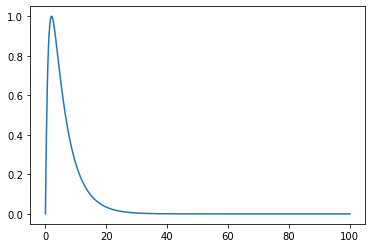

In [2]:
run_dt=0.1
syn_tau1 = 1.
syn_tau2 = 5.
fE = 1e-3
t=np.arange(0,100+run_dt,run_dt)
NE = ((syn_tau1/syn_tau2)**(syn_tau1/(syn_tau2-syn_tau1))-(syn_tau1/syn_tau2)**(syn_tau2/(syn_tau2-syn_tau1)))**-1
uE = NE*(np.exp(-t/syn_tau2)-np.exp(-t/syn_tau1))
plt.plot(t,uE)
ground_truth = np.mean(uE)
print(ground_truth)

In [4]:
neuron = Purkinje_py3()

In [3]:
def recovery_of_local_conductance(run_dt,dV, fE, passive = False, 
                    E = True, loc=58, block='',name= '', 
                    location ='dend'):
    
    neuron = Purkinje_py3()
    
    
    if passive:
        for sec in h.allsec():
            # 检查 section 是否有主动离子通道
            if h.ismembrane("Cav2_1", sec=sec):
                sec.pcabar_Cav2_1 = 0.
            if h.ismembrane("Cav3_1", sec=sec):
                sec.pcabar_Cav3_1 = 0.
            if h.ismembrane("Cav3_2", sec=sec):
                sec.gcabar_Cav3_2 = 0.
            if h.ismembrane("Cav3_3", sec=sec):
                sec.gCav3_3bar_Cav3_3 = 0.
            if h.ismembrane("HCN1", sec=sec):
                sec.gbar_HCN1 = 0.
            if h.ismembrane("Kca1_1", sec=sec):
                sec.gbar_Kca1_1 = 0.
            if h.ismembrane("Kca2_2", sec=sec):
                sec.gkbar_Kca2_2 = 0.
            if h.ismembrane("Kca3_1", sec=sec):
                sec.gkbar_Kca3_1 = 0.
            if h.ismembrane("Kir2_3", sec=sec):
                sec.gkbar_Kir2_3 = 0.
            if h.ismembrane("Kv1_1", sec=sec):
                sec.gbar_Kv1_1 = 0.
            if h.ismembrane("Kv1_5", sec=sec):
                sec.gKur_Kv1_5 = 0.
                sec.gnonspec_Kv1_5 = 0.
            if h.ismembrane("Kv3_3", sec=sec):
                sec.gbar_Kv3_3 = 0.
            if h.ismembrane("Kv3_4", sec=sec):
                sec.gkbar_Kv3_4 = 0.
            if h.ismembrane("Kv4_3", sec=sec):
                sec.gkbar_Kv4_3 = 0.
            if h.ismembrane("Nav1_6", sec=sec):
                sec.gbar_Nav1_6 = 0.
    
    
    if block:
        for sec in h.allsec():
            if h.ismembrane(block, sec=sec):
                # 将电导设置为0
                setattr(sec, name, 0.)
    if passive:
        h.v_init = -63.2
    else:
        h.v_init = -66
             
    h.dt = run_dt
    h.tstop = 200.
    v_clamp = -63.2
    
    recv = h.Vector().record(neuron.soma(0.5)._ref_v)


    # Initialize an excitatory or inhibitory synaptic input
    # make a new stimulator
    stim = h.NetStim()
    
    # attach it to a synapse
    if location == 'dend':
        syn = h.Exp2Syn(neuron.dend[int(loc)](0.9))
    syn.tau1 = 1.  # ms
    syn.tau2 = 5.  # ms
    if E:
        syn.e = 0.  # mV for E input and -100 for I input
    else: 
        syn.e = -100.
    # print(syn.e)
        
    stim.number = 1
    stim.start = 100.  # ms
    ncstim = h.NetCon(stim, syn)
    ncstim.delay = 0.
    ncstim.weight[0] = 0.  # uS


    # Initialize voltage clamp
    vclamp = h.SEClamp(neuron.soma(0.5))
    vclamp.amp1 = v_clamp
    vclamp.dur1 = h.tstop
    vclamp.amp2 = v_clamp - 20.

    irec = h.Vector()
    irec.record(vclamp._ref_i)

    # Function to initialize the simulation
    def initialize():
        h.t = 0
        h.finitialize(h.v_init)
        h.fcurrent()

    # Function to integrate the simulation
    def integrate():
        while h.t < h.tstop:
            h.fadvance()

    # Function to run the simulation
    def go():
        initialize()
        integrate()

    # Main simulation loop
    def main():
    
        Vclamp = np.arange(-100.,-60., dV) 
        Isyn_inj = np.zeros(len(Vclamp))
        vclamp.dur1 = 0.
        vclamp.dur2 = 0.
        vclamp.dur3 = 0.
        ncstim.weight[0] = 0.
        go()
        recv0 = np.array(recv.to_python())
        V_rest = recv0[2000]
        Isyn_inj_t = np.zeros((len(Vclamp),1000))

        for i in range(len(Vclamp)):
            ncstim.weight[0] = 0.
            vclamp.amp1 = Vclamp[i]
            vclamp.dur1 = h.tstop
            go()
            Isyn0 = np.array(irec.to_python())  # Assuming irec is a NEURON Vector
            ncstim.weight[0] = fE
            vclamp.amp1 = Vclamp[i]
            vclamp.dur1 = h.tstop
            go()
            Isyn1 = np.array(irec.to_python())  # Assuming irec is a NEURON Vector
            Isyn= - (Isyn1[1001:] - Isyn0[1001:])
            Isyn_inj[i] = np.mean(Isyn)
            Isyn_inj_t[i,:] = Isyn

            
        A = np.ones((len(Vclamp),2))
        A[:,0] = Vclamp - V_rest
        A1 = Vclamp - V_rest
        x, residuals, rank, singular_values = np.linalg.lstsq(A, Isyn_inj, rcond=None)
        if E:
            mean_local_conductance = - x[1]**2/(x[0]*(0. - V_rest)**2)
            A1 = A1 - (0. - V_rest)
        else:
            mean_local_conductance = - x[1]**2/(x[0]*(-100.-V_rest)**2)
            A1 = A1 - (-100. - V_rest)
            
        traditional_effective_conductance = np.zeros(1000)
        for i in range(1000):
            a = np.sum(A1 * Isyn_inj_t[:,i]) / np.sum(A1**2)  # 计算斜率
            traditional_effective_conductance[i] = - a
            
        traditional_mean_conductance = np.mean(traditional_effective_conductance)
        
        return mean_local_conductance, traditional_mean_conductance
    
    
    mean_local_conductance, traditional_mean_conductance = main()
    return mean_local_conductance, traditional_mean_conductance

In [16]:
fE0 = 1e-4
est_mean_cond, est_trad_mean_cond = recovery_of_local_conductance(0.1, 10., fE0, 
        passive=True, E = True, loc=58, block='',name= '', location ='dend')
print(est_mean_cond, est_trad_mean_cond)
print(fE0*ground_truth)

7.472623240292708e-06 5.841054071716224e-06
7.46802999053033e-06


In [5]:
# Your existing functions and code
def recovery_of_local_conductance_parallel(args,):
    loc0, = args
    est_mean_cond, est_trad_mean_cond = recovery_of_local_conductance(0.1, 10., 6e-3, 
        passive = False, E = False, loc=loc0, block='',name= '', location ='dend')
    
    return est_mean_cond, est_trad_mean_cond

loc=np.arange(0, 1599, 1)
loc.astype(int)

# Create a Pool with desired number of processes (adjust as needed)
num_processes = 55
with Pool(num_processes) as pool:
    # Prepare arguments for parallel processing
    args_list = [(loc0,) for loc0 in loc]

    # Apply the function in parallel
    results = pool.map(recovery_of_local_conductance_parallel, args_list)

# Process the results
estimated_mean_cond = np.zeros((len(loc), 2))
for i, result in enumerate(results): 
    estimated_mean_cond[i, :] = result
    
np.savetxt("estimated_mean_cond_active_dendloc1599_fI6e3.txt", estimated_mean_cond)

KeyboardInterrupt: 

# EPSP

In [37]:
def EPSP(run_dt, fE, passive = False, 
                    E = True, loc=58, block='',name= '', 
                    location ='dend'):
    
    neuron = Purkinje_py3()
    
    
    if passive:
        for sec in h.allsec():
            # 检查 section 是否有主动离子通道
            if h.ismembrane("Cav2_1", sec=sec):
                sec.pcabar_Cav2_1 = 0.
            if h.ismembrane("Cav3_1", sec=sec):
                sec.pcabar_Cav3_1 = 0.
            if h.ismembrane("Cav3_2", sec=sec):
                sec.gcabar_Cav3_2 = 0.
            if h.ismembrane("Cav3_3", sec=sec):
                sec.gCav3_3bar_Cav3_3 = 0.
            if h.ismembrane("HCN1", sec=sec):
                sec.gbar_HCN1 = 0.
            if h.ismembrane("Kca1_1", sec=sec):
                sec.gbar_Kca1_1 = 0.
            if h.ismembrane("Kca2_2", sec=sec):
                sec.gkbar_Kca2_2 = 0.
            if h.ismembrane("Kca3_1", sec=sec):
                sec.gkbar_Kca3_1 = 0.
            if h.ismembrane("Kir2_3", sec=sec):
                sec.gkbar_Kir2_3 = 0.
            if h.ismembrane("Kv1_1", sec=sec):
                sec.gbar_Kv1_1 = 0.
            if h.ismembrane("Kv1_5", sec=sec):
                sec.gKur_Kv1_5 = 0.
                sec.gnonspec_Kv1_5 = 0.
            if h.ismembrane("Kv3_3", sec=sec):
                sec.gbar_Kv3_3 = 0.
            if h.ismembrane("Kv3_4", sec=sec):
                sec.gkbar_Kv3_4 = 0.
            if h.ismembrane("Kv4_3", sec=sec):
                sec.gkbar_Kv4_3 = 0.
            if h.ismembrane("Nav1_6", sec=sec):
                sec.gbar_Nav1_6 = 0.
    
    
    if block:
        for sec in h.allsec():
            if h.ismembrane(block, sec=sec):
                # 将电导设置为0
                setattr(sec, name, 0.)
             
    h.dt = run_dt
    h.tstop = 1000.
    if passive:
        h.v_init = -63.2
    else:
        h.v_init = -66
        
    recv = h.Vector().record(neuron.soma(0.5)._ref_v)


    # Initialize an excitatory or inhibitory synaptic input
    # make a new stimulator
    stim = h.NetStim()
    
    # attach it to a synapse
    if location == 'dend':
        syn = h.Exp2Syn(neuron.dend[int(loc)](0.9))
    syn.tau1 = 1.  # ms
    syn.tau2 = 5.  # ms
    if E:
        syn.e = 0.  # mV for E input and -0 for I input
    else: 
        syn.e = -100.
    # print(syn.e)
        
    stim.number = 1
    stim.start = 100.  # ms
    ncstim = h.NetCon(stim, syn)
    ncstim.delay = 0.
    ncstim.weight[0] = 0.  # uS

    # Function to initialize the simulation
    def initialize():
        h.t = 0
        h.finitialize(h.v_init)
        h.fcurrent()

    # Function to integrate the simulation
    def integrate():
        while h.t < h.tstop:
            h.fadvance()

    # Function to run the simulation
    def go():
        initialize()
        integrate()

    # Main simulation loop
    def main():
    
        ncstim.weight[0] = fE
        go()
        recv0 = np.array(recv.to_python())
        plt.plot(recv0)
        return recv0   
    recv0 = main()
    return recv0

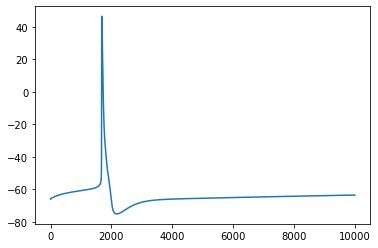

In [34]:
recv0 = EPSP(0.1, 0, passive = False, 
                    E = False, loc=58, block='', name= '', 
                    location ='dend')

In [32]:
recv0[-1]

-65.45440449153028